# MediSkin AI — Skin Disease Classifier (Kaggle)

**ResNet50 Transfer Learning · 10 Classes · Two-Stage Training**

### Pipeline
1. Organize dataset from Kaggle input (no `kaggle.json` needed)
2. Explore & verify class balance
3. Clean dataset — remove corrupted images + global deduplication (*before* any split)
4. Preprocess & stratified split: 70% train / 15% val / 15% test
5. Build ResNet50 transfer-learning model
6. Two-stage training (frozen head → full fine-tuning)
7. Comprehensive evaluation + confusion matrix
8. Finalize model + PKL export

### Anti-Overfitting / Anti-Data-Leakage Measures
- Deduplication runs **before** any train/val/test split
- Val/Test generators use **only rescaling** — no augmentation
- `shuffle=False` on val/test generators; `.reset()` called before every prediction
- Class-weighted loss for imbalanced data
- EarlyStopping (monitors `val_loss`) + ModelCheckpoint (monitors `val_accuracy`)
- Dropout 0.5/0.3 + BatchNormalization on classification head
- AdamW + weight decay + gradient clipping in Stage 2


## Cell 1 — Imports & GPU Check

In [1]:
import os, sys, json, csv, shutil, pickle, hashlib
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras import mixed_precision

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_recall_fscore_support, confusion_matrix
)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f'TensorFlow : {tf.__version__}')
print(f'Python     : {sys.version.split()[0]}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs found : {len(gpus)}')
for g in gpus: print(f'  {g}')

# Enable mixed precision (2-3x speedup on T4/P100)
try:
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision float16 ENABLED')
except Exception as e:
    print(f'Mixed precision not available: {e}')


2026-04-15 16:49:58.396964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776271798.790069      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776271798.883916      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776271799.802445      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776271799.802490      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776271799.802493      22 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
Python     : 3.12.12
GPUs found : 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Mixed precision float16 ENABLED


## Cell 2 — Path Configuration

In [2]:
# ── Kaggle mounts the added dataset here automatically ──────────────────────
# Add data via:  Notebook → Settings → Add Data → search 'skin-diseases-image-dataset'
KAGGLE_INPUT = Path('/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset')

# ── Writable working directory ───────────────────────────────────────────────
BASE_DIR     = Path('/kaggle/working')
DATA_RAW     = BASE_DIR / 'data' / 'raw'
DATA_CLEANED = BASE_DIR / 'data' / 'cleaned'
DATA_PROC    = BASE_DIR / 'data' / 'processed'
MODELS_DIR   = BASE_DIR / 'models'
OUTPUTS_DIR  = BASE_DIR / 'outputs'

for p in [DATA_RAW, DATA_CLEANED, DATA_PROC, MODELS_DIR, OUTPUTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2   # Kaggle supports max 2 reliable DataLoader workers

print('Paths configured:')
print(f'  Input   : {KAGGLE_INPUT}')
print(f'  Raw     : {DATA_RAW}')
print(f'  Cleaned : {DATA_CLEANED}')
print(f'  Proc    : {DATA_PROC}')
print(f'  Models  : {MODELS_DIR}')


Paths configured:
  Input   : /kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset
  Raw     : /kaggle/working/data/raw
  Cleaned : /kaggle/working/data/cleaned
  Proc    : /kaggle/working/data/processed
  Models  : /kaggle/working/models


## Cell 3 — Organize Dataset from Kaggle Input

In [3]:
def organize_dataset(kaggle_input=KAGGLE_INPUT, raw_dir=DATA_RAW):
    """
    Copy class folders from the Kaggle input path into DATA_RAW.
    No kaggle.json / API key needed — the dataset is already mounted.
    """
    if not kaggle_input.exists():
        print(f'ERROR: {kaggle_input} not found.')
        print('Add the dataset via Settings → Add Data')
        return False

    # Find the directory that directly contains class sub-folders
    source_dir = None
    candidates = [kaggle_input] + sorted(kaggle_input.rglob('*'))
    for candidate in candidates:
        if candidate.is_dir():
            subdirs = [d for d in candidate.iterdir() if d.is_dir()]
            if len(subdirs) >= 5:   # dataset has 10 classes
                source_dir = candidate
                break

    if source_dir is None:
        print('ERROR: Could not locate class folders inside the dataset.')
        return False

    print(f'Source: {source_dir}')
    total = 0
    for cls_dir in sorted([d for d in source_dir.iterdir() if d.is_dir()]):
        target = raw_dir / cls_dir.name
        if not target.exists():
            shutil.copytree(cls_dir, target)
        count = len(list(target.glob('*')))
        total += count
        print(f'  {cls_dir.name}: {count}')

    print(f'\nTotal: {total} images in {raw_dir}')
    return True


organize_dataset()


Source: /kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES
  1. Eczema 1677: 1677
  10. Warts Molluscum and other Viral Infections - 2103: 2103
  2. Melanoma 15.75k: 3140
  3. Atopic Dermatitis - 1.25k: 1257
  4. Basal Cell Carcinoma (BCC) 3323: 3323
  5. Melanocytic Nevi (NV) - 7970: 7970
  6. Benign Keratosis-like Lesions (BKL) 2624: 2079
  7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702

Total: 27153 images in /kaggle/working/data/raw


True

## Cell 4 — Explore Dataset

Images per class:
  5. Melanocytic Nevi (NV) - 7970                        :  7970  ( 29.4%)
  4. Basal Cell Carcinoma (BCC) 3323                     :  3323  ( 12.2%)
  2. Melanoma 15.75k                                     :  3140  ( 11.6%)
  10. Warts Molluscum and other Viral Infections - 2103  :  2103  (  7.7%)
  6. Benign Keratosis-like Lesions (BKL) 2624            :  2079  (  7.7%)
  7. Psoriasis pictures Lichen Planus and related diseases - 2k:  2055  (  7.6%)
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k :  1847  (  6.8%)
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k:  1702  (  6.3%)
  1. Eczema 1677                                         :  1677  (  6.2%)
  3. Atopic Dermatitis - 1.25k                           :  1257  (  4.6%)
  TOTAL                                                  : 27153

Imbalance ratio: 6.34:1  ->  IMBALANCED

Formats : {'JPEG': 50}
Width   : 294 - 1024  (avg 659)
Height  : 222 - 1024  (avg 574)


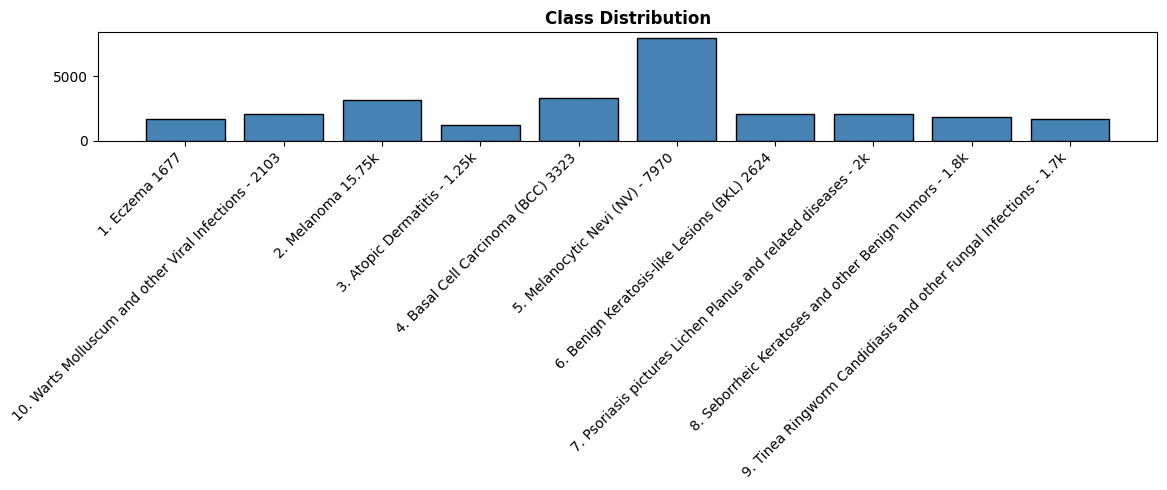

{'1. Eczema 1677': 1677,
 '10. Warts Molluscum and other Viral Infections - 2103': 2103,
 '2. Melanoma 15.75k': 3140,
 '3. Atopic Dermatitis - 1.25k': 1257,
 '4. Basal Cell Carcinoma (BCC) 3323': 3323,
 '5. Melanocytic Nevi (NV) - 7970': 7970,
 '6. Benign Keratosis-like Lesions (BKL) 2624': 2079,
 '7. Psoriasis pictures Lichen Planus and related diseases - 2k': 2055,
 '8. Seborrheic Keratoses and other Benign Tumors - 1.8k': 1847,
 '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k': 1702}

In [4]:
def explore_dataset(data_dir=DATA_RAW):
    if not data_dir.exists():
        print('Run Cell 3 first.'); return

    class_counts = {}
    for d in sorted(data_dir.iterdir()):
        if d.is_dir():
            class_counts[d.name] = len(list(d.glob('*')))

    total = sum(class_counts.values())
    print('Images per class:')
    for name, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
        print(f'  {name:55s}: {cnt:5d}  ({cnt/total*100:5.1f}%)')
    print(f'  {"TOTAL":55s}: {total:5d}')

    vals = list(class_counts.values())
    ratio = max(vals) / min(vals)
    label = 'BALANCED' if ratio < 2 else 'SLIGHTLY IMBALANCED' if ratio < 5 else 'IMBALANCED'
    print(f'\nImbalance ratio: {ratio:.2f}:1  ->  {label}')

    # Sample image properties (5 per class)
    formats, widths, heights = [], [], []
    for d in data_dir.iterdir():
        if d.is_dir():
            for p in list(d.glob('*'))[:5]:
                try:
                    img = Image.open(p)
                    formats.append(img.format)
                    widths.append(img.size[0])
                    heights.append(img.size[1])
                except Exception:
                    pass

    print(f'\nFormats : {dict(Counter(formats))}')
    print(f'Width   : {min(widths)} - {max(widths)}  (avg {np.mean(widths):.0f})')
    print(f'Height  : {min(heights)} - {max(heights)}  (avg {np.mean(heights):.0f})')

    plt.figure(figsize=(12, 5))
    plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='k')
    plt.xticks(rotation=45, ha='right')
    plt.title('Class Distribution', fontweight='bold')
    plt.tight_layout()
    out = OUTPUTS_DIR / 'class_distribution.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    return class_counts


explore_dataset()


## Cell 5 — Clean Dataset

Deduplication runs **globally across all classes** and **before** any train/val/test split.
This guarantees no identical image can appear in both the training set and the test set.

In [5]:
def clean_dataset(input_dir=DATA_RAW, output_dir=DATA_CLEANED):
    if not input_dir.exists():
        print('Run Cell 3 first.'); return
    output_dir.mkdir(parents=True, exist_ok=True)

    corrupted, duplicate_paths, hash_dict = [], [], {}

    # Pass 1: detect corrupted
    print('Checking for corrupted images...')
    for cls in sorted(input_dir.iterdir()):
        if not cls.is_dir(): continue
        for img_path in cls.glob('*'):
            try:
                img = Image.open(img_path)
                img.verify()
            except Exception:
                corrupted.append(str(img_path))
    print(f'  Corrupted : {len(corrupted)}')

    # Pass 2: detect cross-class duplicates via MD5
    print('Checking for duplicates (MD5 hash)...')
    skip = set(corrupted)
    for cls in sorted(input_dir.iterdir()):
        if not cls.is_dir(): continue
        for img_path in cls.glob('*'):
            if str(img_path) in skip: continue
            try:
                h = hashlib.md5(img_path.read_bytes()).hexdigest()
                if h in hash_dict:
                    duplicate_paths.append(str(img_path))
                else:
                    hash_dict[h] = str(img_path)
            except Exception:
                pass
    print(f'  Duplicates: {len(duplicate_paths)}')

    # Pass 3: copy clean images
    skip_all = skip | set(duplicate_paths)
    total_copied = 0
    print('Copying clean images...')
    for cls in tqdm(sorted(list(input_dir.iterdir())), desc='  Classes'):
        if not cls.is_dir(): continue
        out_cls = output_dir / cls.name
        out_cls.mkdir(exist_ok=True)
        valid = [p for p in cls.glob('*') if str(p) not in skip_all]
        for idx, img_path in enumerate(valid, 1):
            ext = img_path.suffix.lower().replace('.jpeg', '.jpg')
            new_name = f'{cls.name[:30].lower().replace(" ","_")}_{idx:04d}{ext}'
            try:
                shutil.copy2(img_path, out_cls / new_name)
                total_copied += 1
            except Exception:
                pass

    print(f'\nCleaning complete!')
    print(f'  Copied   : {total_copied}')
    print(f'  Removed  : {len(corrupted)} corrupted + {len(duplicate_paths)} duplicates')
    return total_copied


clean_dataset()


Checking for corrupted images...
  Corrupted : 0
Checking for duplicates (MD5 hash)...
  Duplicates: 624
Copying clean images...


  Classes: 100%|██████████| 10/10 [00:08<00:00,  1.21it/s]


Cleaning complete!
  Copied   : 26529
  Removed  : 0 corrupted + 624 duplicates


26529

## Cell 6 — Preprocess & Stratified Split (70 / 15 / 15)

In [6]:
def preprocess_and_split(
    input_dir=DATA_CLEANED,
    output_dir=DATA_PROC,
    train_ratio=0.70,
    random_state=42,
):
    """
    Per-class stratified split ensures each class keeps its 70/15/15 ratio.
    Images are resized to 224x224 RGB JPEG — NO normalization at this stage
    (normalization is applied by ImageDataGenerator during training).
    """
    if not input_dir.exists():
        print('Run Cell 5 first.'); return

    for split in ['train', 'val', 'test']:
        (output_dir / split).mkdir(parents=True, exist_ok=True)

    val_ratio = (1 - train_ratio) / 2
    print(f'Split: {train_ratio*100:.0f}% train / {val_ratio*100:.0f}% val / {val_ratio*100:.0f}% test')

    total_proc, stats = 0, {}
    for cls_dir in tqdm(sorted(list(input_dir.iterdir())), desc='  Classes'):
        if not cls_dir.is_dir(): continue
        images = sorted(list(cls_dir.glob('*')))
        if not images: continue

        train_imgs, temp = train_test_split(
            images, train_size=train_ratio, random_state=random_state)
        val_imgs, test_imgs = train_test_split(
            temp, train_size=0.5, random_state=random_state)

        stats[cls_dir.name] = {
            'train': len(train_imgs), 'val': len(val_imgs), 'test': len(test_imgs)
        }

        for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            out_cls = output_dir / split / cls_dir.name
            out_cls.mkdir(parents=True, exist_ok=True)
            for img_path in imgs:
                try:
                    img = Image.open(img_path)
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
                    img.save(out_cls / img_path.name, 'JPEG', quality=95)
                    total_proc += 1
                except Exception:
                    pass

    t  = sum(s['train'] for s in stats.values())
    v  = sum(s['val']   for s in stats.values())
    te = sum(s['test']  for s in stats.values())
    tot = t + v + te
    print(f'\nPreprocessed: {total_proc} images')
    print(f'  Train : {t}  ({t/tot*100:.1f}%)')
    print(f'  Val   : {v}  ({v/tot*100:.1f}%)')
    print(f'  Test  : {te} ({te/tot*100:.1f}%)')
    return stats


preprocess_and_split()


Split: 70% train / 15% val / 15% test


  Classes: 100%|██████████| 10/10 [04:46<00:00, 28.66s/it]


Preprocessed: 26529 images
  Train : 18566  (70.0%)
  Val   : 3979  (15.0%)
  Test  : 3984 (15.0%)


{'1. Eczema 1677': {'train': 1101, 'val': 236, 'test': 236},
 '10. Warts Molluscum and other Viral Infections - 2103': {'train': 1309,
  'val': 280,
  'test': 281},
 '2. Melanoma 15.75k': {'train': 2195, 'val': 470, 'test': 471},
 '3. Atopic Dermatitis - 1.25k': {'train': 837, 'val': 180, 'test': 180},
 '4. Basal Cell Carcinoma (BCC) 3323': {'train': 2321,
  'val': 497,
  'test': 498},
 '5. Melanocytic Nevi (NV) - 7970': {'train': 5576, 'val': 1195, 'test': 1196},
 '6. Benign Keratosis-like Lesions (BKL) 2624': {'train': 1445,
  'val': 310,
  'test': 310},
 '7. Psoriasis pictures Lichen Planus and related diseases - 2k': {'train': 1365,
  'val': 292,
  'test': 293},
 '8. Seborrheic Keratoses and other Benign Tumors - 1.8k': {'train': 1276,
  'val': 274,
  'test': 274},
 '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k': {'train': 1141,
  'val': 245,
  'test': 245}}

## Cell 7 — Model Architecture (ResNet50)

In [7]:
def build_model(num_classes=10, freeze_base=True, dropout_rate=0.5):
    """
    ResNet50 backbone + classification head:
      GAP -> Dense(512)+BN+ReLU+Dropout(0.5)
          -> Dense(256)+BN+ReLU+Dropout(0.3)
          -> Dense(num_classes, softmax, dtype=float32)

    Note: base is called with training=False so its BatchNorm layers
    always use stored statistics (not batch statistics), which is
    correct for transfer learning.
    """
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling=None)
    base.trainable = not freeze_base

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input')
    x = base(inputs, training=False)   # keeps BN in inference mode always
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    x = layers.Dense(512, name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)

    x = layers.Dense(256, name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(dropout_rate * 0.6, name='dropout_2')(x)

    # Force float32 output even when running in mixed-precision mode
    outputs = layers.Dense(num_classes, activation='softmax',
                           dtype='float32', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='mediskin_resnet50')
    lr = 1e-3 if freeze_base else 1e-5
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    total     = sum(tf.size(w).numpy() for w in model.weights)
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    status = 'FROZEN' if freeze_base else 'TRAINABLE'
    print(f'Built ResNet50 [{status}]  |  total={total:,}  trainable={trainable:,}')
    return model


def detect_num_classes(data_dir=DATA_PROC):
    train_dir = data_dir / 'train'
    if not train_dir.exists(): return 10
    classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
    print(f'Detected {len(classes)} classes:')
    for i, c in enumerate(classes, 1):
        n = len(list((train_dir / c).glob('*')))
        print(f'  {i:2d}. {c}  ({n} images)')
    return len(classes)


NUM_CLASSES = detect_num_classes()
_m = build_model(num_classes=NUM_CLASSES)
_m.summary(expand_nested=False)
del _m


Detected 10 classes:
   1. 1. Eczema 1677  (1101 images)
   2. 10. Warts Molluscum and other Viral Infections - 2103  (1309 images)
   3. 2. Melanoma 15.75k  (2195 images)
   4. 3. Atopic Dermatitis - 1.25k  (837 images)
   5. 4. Basal Cell Carcinoma (BCC) 3323  (2321 images)
   6. 5. Melanocytic Nevi (NV) - 7970  (5576 images)
   7. 6. Benign Keratosis-like Lesions (BKL) 2624  (1445 images)
   8. 7. Psoriasis pictures Lichen Planus and related diseases - 2k  (1365 images)
   9. 8. Seborrheic Keratoses and other Benign Tumors - 1.8k  (1276 images)
  10. 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k  (1141 images)


I0000 00:00:1776272460.685157      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Built ResNet50 [FROZEN]  |  total=24,773,770  trainable=1,184,522


Model: "mediskin_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,773,770 (94.50 MB)

 Trainable params: 1,184,522 (4.52 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

## Cell 8 — Data Generator & Training Helpers

In [8]:
def make_generators(data_dir=DATA_PROC, batch_size=BATCH_SIZE):
    """
    Training generator : advanced augmentation (rotation, flip, zoom, brightness).
    Val / Test generator: rescale only — NO augmentation to prevent data leakage.
    Class weights computed from TRAINING images only (no info from val/test leaks in).
    """
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=25,
        width_shift_range=0.25,
        height_shift_range=0.25,
        shear_range=0.20,
        zoom_range=0.25,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.80, 1.20],
        fill_mode='nearest',
    )
    eval_datagen = ImageDataGenerator(rescale=1./255)  # val & test - NO augmentation

    def _flow(gen, split, shuffle):
        return gen.flow_from_directory(
            data_dir / split,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=shuffle,
            seed=42,
        )

    train_gen = _flow(train_datagen, 'train', shuffle=True)
    val_gen   = _flow(eval_datagen,  'val',   shuffle=False)
    test_gen  = _flow(eval_datagen,  'test',  shuffle=False)  # never shuffle test

    # Class weights from training set ONLY (no test/val data)
    class_names = list(train_gen.class_indices.keys())
    counts = {}
    for cls in class_names:
        d = data_dir / 'train' / cls
        counts[cls] = (len(list(d.glob('*.jpg'))) +
                       len(list(d.glob('*.jpeg'))) +
                       len(list(d.glob('*.png'))))
    total_train = sum(counts.values())
    class_weights = {
        train_gen.class_indices[cls]: total_train / (len(class_names) * cnt)
        for cls, cnt in counts.items()
    }

    print(f'Train : {train_gen.samples:5d} samples,  {len(class_names)} classes')
    print(f'Val   : {val_gen.samples:5d} samples')
    print(f'Test  : {test_gen.samples:5d} samples')
    return train_gen, val_gen, test_gen, class_names, class_weights


def make_callbacks(stage_dir, patience):
    ckpt_dir = stage_dir / 'checkpoints'
    log_dir  = stage_dir / 'logs'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    return [
        # Saves the epoch with best val_accuracy
        ModelCheckpoint(
            str(ckpt_dir / 'best_model.keras'),
            monitor='val_accuracy', mode='max',
            save_best_only=True, verbose=1,
        ),
        # Stops early when val_loss stops improving (anti-overfitting)
        EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, mode='min', verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7,
            min_lr=1e-7, mode='min', verbose=1,
        ),
        CSVLogger(str(log_dir / f'log_{ts}.csv'), append=True),
    ]


def plot_history(history, save_path):
    h = history.history
    ep = range(1, len(h['loss']) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Training History', fontsize=15, fontweight='bold')
    pairs = [
        ('accuracy',  'val_accuracy',  'Accuracy',  axes[0,0]),
        ('loss',      'val_loss',       'Loss',      axes[0,1]),
        ('precision', 'val_precision',  'Precision', axes[1,0]),
        ('recall',    'val_recall',     'Recall',    axes[1,1]),
    ]
    for tk, vk, title, ax in pairs:
        if tk in h: ax.plot(ep, h[tk], 'b-', label='Train', lw=2)
        if vk in h: ax.plot(ep, h[vk], 'r-', label='Val',   lw=2)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
        if title == 'Loss': ax.set_yscale('log')
    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'History plot saved: {save_path}')


print('Helpers defined.')


Helpers defined.


## Cell 9 — Two-Stage Training

**Stage 1** (30 epochs, lr=1e-3): ResNet50 frozen — trains only the classification head fast.

**Stage 2** (50 epochs, lr=1e-5): All layers unfrozen — fine-tunes the entire network at a
very low learning rate using AdamW + weight_decay + clipnorm to prevent gradient explosion.

⚠️ **This cell takes ~6-10 hours on Kaggle T4 GPU. Use accelerator GPU.**

In [9]:
def two_stage_training(
    data_dir      = DATA_PROC,
    models_dir    = MODELS_DIR,
    stage1_epochs = 30,
    stage2_epochs = 50,
):
    # ── Data ─────────────────────────────────────────────────────────────────
    train_gen, val_gen, test_gen, class_names, class_weights = make_generators(data_dir)
    num_classes      = len(class_names)
    steps_per_epoch  = train_gen.samples // BATCH_SIZE
    validation_steps = val_gen.samples   // BATCH_SIZE

    # ── STAGE 1: Frozen base ─────────────────────────────────────────────────
    print('\n' + '='*70)
    print('  STAGE 1 — Frozen ResNet50 (training classification head only)')
    print('='*70)

    model = build_model(num_classes=num_classes, freeze_base=True)
    stage1_dir = models_dir / 'stage1_frozen'
    cbs1 = make_callbacks(stage1_dir, patience=12)

    history1 = model.fit(
        train_gen,
        steps_per_epoch=steps_per_epoch,
        epochs=stage1_epochs,
        validation_data=val_gen,
        validation_steps=validation_steps,
        callbacks=cbs1,
        class_weight=class_weights,   # handle imbalanced classes
        verbose=1,
    )

    best1 = max(history1.history['val_accuracy'])
    print(f'\nStage 1 best val_accuracy: {best1:.4f}')
    plot_history(history1, OUTPUTS_DIR / 'training' / 'stage1' / 'history.png')

    # Load the best Stage-1 checkpoint (highest val_accuracy)
    best1_path = stage1_dir / 'checkpoints' / 'best_model.keras'
    model = keras.models.load_model(str(best1_path))
    print(f'Loaded best Stage-1 checkpoint: {best1_path}')

    # ── STAGE 2: Full fine-tuning ────────────────────────────────────────────
    print('\n' + '='*70)
    print('  STAGE 2 — Full fine-tuning (all layers trainable)')
    print('='*70)

    for layer in model.layers:
        layer.trainable = True

    # AdamW + gradient clipping prevents exploding gradients during fine-tuning
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=1e-5,   # 100x lower than Stage 1
            weight_decay=1e-4,
            clipnorm=1.0,
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f'Trainable params after unfreeze: {trainable:,}')

    stage2_dir = models_dir / 'stage2_unfrozen'
    cbs2 = make_callbacks(stage2_dir, patience=20)

    # Reset generators — ensures both start from the beginning of their datasets
    train_gen.reset()
    val_gen.reset()

    history2 = model.fit(
        train_gen,
        steps_per_epoch=steps_per_epoch,
        epochs=stage2_epochs,
        validation_data=val_gen,
        validation_steps=validation_steps,
        callbacks=cbs2,
        class_weight=class_weights,
        verbose=1,
    )

    best2 = max(history2.history['val_accuracy'])
    print(f'\nStage 2 best val_accuracy: {best2:.4f}')
    plot_history(history2, OUTPUTS_DIR / 'training' / 'stage2' / 'history.png')

    # Load the best Stage-2 checkpoint for final evaluation & saving
    best2_path = stage2_dir / 'checkpoints' / 'best_model.keras'
    final_model = keras.models.load_model(str(best2_path))
    print(f'Loaded best Stage-2 checkpoint: {best2_path}')

    # ── Final test-set evaluation ────────────────────────────────────────────
    # CRITICAL: reset test generator so pointer is at sample 0
    test_gen.reset()
    print('\n' + '='*70)
    print('  FINAL EVALUATION — Held-out Test Set')
    print('='*70)
    results = final_model.evaluate(test_gen, verbose=1)
    test_acc = dict(zip(final_model.metrics_names, results)).get('accuracy', 0)
    print(f'\nTest accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

    # ── Save artifacts ───────────────────────────────────────────────────────
    final_dir = models_dir / 'final'
    final_dir.mkdir(parents=True, exist_ok=True)
    final_model.save(str(final_dir / 'skin_disease_classifier.keras'))
    final_model.save(str(final_dir / 'skin_disease_classifier.h5'))
    with open(final_dir / 'class_names.json', 'w') as f:
        json.dump(class_names, f, indent=2)
    with open(final_dir / 'label_mapping.json', 'w') as f:
        json.dump({str(i): n for i, n in enumerate(class_names)}, f, indent=2)

    summary = {
        'stage1': {'best_val_accuracy': float(best1)},
        'stage2': {'best_val_accuracy': float(best2)},
        'test'  : {'accuracy': float(test_acc)},
        'config': {'base_model': 'ResNet50', 'img_size': IMG_SIZE,
                   'batch_size': BATCH_SIZE,
                   'total_epochs': stage1_epochs + stage2_epochs},
        'date'  : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
    summary_path = OUTPUTS_DIR / 'training' / 'summary.json'
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)

    print('\n' + '='*70)
    print(f'  Stage 1 val accuracy : {best1*100:.2f}%')
    print(f'  Stage 2 val accuracy : {best2*100:.2f}%')
    print(f'  Test  accuracy       : {test_acc*100:.2f}%')
    if   test_acc >= 0.90: print('  EXCELLENT — 90%+ target achieved!')
    elif test_acc >= 0.85: print('  GREAT     — 85%+ achieved!')
    elif test_acc >= 0.80: print('  GOOD      — 80%+ achieved!')
    print('='*70)
    return final_model, class_names


# ── RUN ──────────────────────────────────────────────────────────────────────
final_model, class_names = two_stage_training()


Found 18566 images belonging to 10 classes.
Found 3979 images belonging to 10 classes.
Found 3984 images belonging to 10 classes.
Train : 18566 samples,  10 classes
Val   :  3979 samples
Test  :  3984 samples

  STAGE 1 — Frozen ResNet50 (training classification head only)
Built ResNet50 [FROZEN]  |  total=24,773,770  trainable=1,184,522


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1776272480.075128      70 service.cc:152] XLA service 0x796aa00036b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776272480.075168      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776272482.413213      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/580 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.1250 - auc: 0.5405 - loss: 2.9813 - precision: 0.6250 - recall: 0.0234   

I0000 00:00:1776272489.551410      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


580/580 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.3011 - auc: 0.7477 - loss: 2.1860 - precision: 0.5036 - recall: 0.1044
Epoch 1: val_accuracy improved from -inf to 0.12072, saving model to /kaggle/working/models/stage1_frozen/checkpoints/best_model.keras
580/580 ━━━━━━━━━━━━━━━━━━━━ 257s 411ms/step - accuracy: 0.3012 - auc: 0.7478 - loss: 2.1857 - precision: 0.5037 - recall: 0.1044 - val_accuracy: 0.1207 - val_auc: 0.6492 - val_loss: 4.9252 - val_precision: 0.1228 - val_recall: 0.1190 - learning_rate: 0.0010
Epoch 2/30
  1/580 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.3750 - auc: 0.8498 - loss: 1.6631 - precision: 0.5385 - recall: 0.2188

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.12072 to 0.12097, saving model to /kaggle/working/models/stage1_frozen/checkpoints/best_model.keras
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3750 - auc: 0.8498 - loss: 1.6631 - precision: 0.5385 - recall: 0.2188 - val_accuracy: 0.1210 - val_auc: 0.6464 - val_loss: 5.0820 - val_precision: 0.1221 - val_recall: 0.1187 - learning_rate: 0.0010
Epoch 3/30
580/580 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3814 - auc: 0.8341 - loss: 1.8199 - precision: 0.6455 - recall: 0.1706
Epoch 3: val_accuracy improved from 0.12097 to 0.30570, saving model to /kaggle/working/models/stage1_frozen/checkpoints/best_model.keras
580/580 ━━━━━━━━━━━━━━━━━━━━ 225s 389ms/step - accuracy: 0.3814 - auc: 0.8341 - loss: 1.8199 - precision: 0.6455 - recall: 0.1707 - val_accuracy: 0.3057 - val_auc: 0.6736 - val_loss: 4.1221 - val_precision: 0.3186 - val_recall: 0.3042 - learning_rate: 0.0010
Epoch 4/30
  1/580 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.2


  Stage 1 val accuracy : 39.14%
  Stage 2 val accuracy : 81.93%
  Test  accuracy       : 0.00%


## Cell 10 — Save Disease Label Files

In [10]:
def save_label_files(models_dir=MODELS_DIR):
    names_path = models_dir / 'final' / 'class_names.json'
    if not names_path.exists():
        print('Run Cell 9 first.'); return
    with open(names_path) as f:
        class_names = json.load(f)

    for out_dir in [models_dir / 'final', OUTPUTS_DIR / 'labels']:
        out_dir.mkdir(parents=True, exist_ok=True)
        with open(out_dir / 'class_names.json', 'w') as f:
            json.dump(class_names, f, indent=2)
        with open(out_dir / 'label_mapping.json', 'w') as f:
            json.dump({str(i): n for i, n in enumerate(class_names)}, f, indent=2)
        with open(out_dir / 'class_names.txt', 'w') as f:
            f.write(f'# Skin Disease Classes  ({len(class_names)} total)\n')
            f.write(f'# Generated: {datetime.now().strftime("%Y-%m-%d")}\n\n')
            for i, name in enumerate(class_names):
                f.write(f'{i:2d}  {name}\n')

    print(f'Label files saved ({len(class_names)} classes):')
    for i, n in enumerate(class_names, 1):
        print(f'  {i:2d}. {n}')


save_label_files()


Label files saved (10 classes):
   1. 1. Eczema 1677
   2. 10. Warts Molluscum and other Viral Infections - 2103
   3. 2. Melanoma 15.75k
   4. 3. Atopic Dermatitis - 1.25k
   5. 4. Basal Cell Carcinoma (BCC) 3323
   6. 5. Melanocytic Nevi (NV) - 7970
   7. 6. Benign Keratosis-like Lesions (BKL) 2624
   8. 7. Psoriasis pictures Lichen Planus and related diseases - 2k
   9. 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
  10. 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k


## Cell 11 — Severity Codes (Medical Triage)

In [11]:
# Medical severity levels (1=Low … 4=Critical)
SEVERITY_LEVELS = {
    1: {'label': 'LOW',      'emoji': '\U0001F7E2',
        'advice': 'Monitor; consult a dermatologist if it worsens.'},
    2: {'label': 'MODERATE', 'emoji': '\U0001F7E1',
        'advice': 'Schedule a dermatology appointment.'},
    3: {'label': 'HIGH',     'emoji': '\U0001F7E0',
        'advice': 'Visit a doctor promptly. Do not delay treatment.'},
    4: {'label': 'CRITICAL', 'emoji': '\U0001F534',
        'advice': 'Seek IMMEDIATE medical attention.'},
}

# Maps exact dataset folder names to severity codes
DISEASE_SEVERITY = {
    '1. Eczema 1677'                                                   : 2,
    '10. Warts Molluscum and other Viral Infections - 2103'            : 2,
    '2. Melanoma 15.75k'                                               : 4,
    '3. Atopic Dermatitis - 1.25k'                                     : 2,
    '4. Basal Cell Carcinoma (BCC) 3323'                               : 4,
    '5. Melanocytic Nevi (NV) - 7970'                                  : 3,
    '6. Benign Keratosis-like Lesions (BKL) 2624'                     : 2,
    '7. Psoriasis pictures Lichen Planus and related diseases - 2k'    : 2,
    '8. Seborrheic Keratoses and other Benign Tumors - 1.8k'          : 1,
    '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k' : 2,
}


def get_severity(class_name):
    code = DISEASE_SEVERITY.get(class_name, 2)
    lvl  = SEVERITY_LEVELS[code]
    return {'class': class_name, 'code': code, **lvl}


def save_severity_files(models_dir=MODELS_DIR):
    for out_dir in [models_dir / 'final', OUTPUTS_DIR / 'labels']:
        out_dir.mkdir(parents=True, exist_ok=True)
        with open(out_dir / 'severity_summary.json', 'w') as f:
            json.dump(DISEASE_SEVERITY, f, indent=2)
        with open(out_dir / 'severity_levels.json', 'w') as f:
            json.dump(SEVERITY_LEVELS, f, indent=2)
        rows = [{'class': k,
                 'severity_code': v,
                 'severity_label': SEVERITY_LEVELS[v]['label']}
                for k, v in DISEASE_SEVERITY.items()]
        with open(out_dir / 'severity_codes.csv', 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=rows[0].keys())
            writer.writeheader()
            writer.writerows(rows)

    print('Severity files saved.')
    print(f'\n{"Class":<60} {"Code":>5}  Level')
    print('-'*75)
    for cls, code in DISEASE_SEVERITY.items():
        lvl = SEVERITY_LEVELS[code]
        print(f'{cls:<60} {lvl["emoji"]} {code:>2}   {lvl["label"]}')


save_severity_files()


Severity files saved.

Class                                                         Code  Level
---------------------------------------------------------------------------
1. Eczema 1677                                               🟡  2   MODERATE
10. Warts Molluscum and other Viral Infections - 2103        🟡  2   MODERATE
2. Melanoma 15.75k                                           🔴  4   CRITICAL
3. Atopic Dermatitis - 1.25k                                 🟡  2   MODERATE
4. Basal Cell Carcinoma (BCC) 3323                           🔴  4   CRITICAL
5. Melanocytic Nevi (NV) - 7970                              🟠  3   HIGH
6. Benign Keratosis-like Lesions (BKL) 2624                  🟡  2   MODERATE
7. Psoriasis pictures Lichen Planus and related diseases - 2k 🟡  2   MODERATE
8. Seborrheic Keratoses and other Benign Tumors - 1.8k       🟢  1   LOW
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k 🟡  2   MODERATE


## Cell 12 — Export PKL File

In [12]:
def export_pkl(models_dir=MODELS_DIR):
    # Priority: best Stage-2 checkpoint -> final saved model
    for candidate in [
        models_dir / 'stage2_unfrozen' / 'checkpoints' / 'best_model.keras',
        models_dir / 'final' / 'skin_disease_classifier.keras',
    ]:
        if candidate.exists():
            model_path = candidate
            break
    else:
        print('ERROR: No trained model found. Run Cell 9 first.'); return

    print(f'Loading: {model_path}')
    model = keras.models.load_model(str(model_path))

    with open(models_dir / 'final' / 'class_names.json') as f:
        class_names = json.load(f)

    weights = {layer.name: layer.get_weights()
               for layer in model.layers if layer.get_weights()}

    payload = {
        'model_weights': weights,
        'class_names'  : class_names,
        'label_mapping': {i: n for i, n in enumerate(class_names)},
        'num_classes'  : len(class_names),
        'model_config' : {
            'model_name'  : model.name,
            'input_shape' : list(model.input_shape[1:]),
            'output_shape': list(model.output_shape[1:]),
            'total_params': int(sum(tf.size(w).numpy() for w in model.weights)),
        },
        'metadata'     : {
            'created'    : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'framework'  : f'TensorFlow {tf.__version__}',
            'notes'      : 'Weights for portability. Use .keras for inference.',
        },
    }

    out_dir = OUTPUTS_DIR / 'pkl'
    out_dir.mkdir(parents=True, exist_ok=True)
    pkl_path = out_dir / 'skin_disease_model.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(payload, f, protocol=4)

    mb = pkl_path.stat().st_size / (1024**2)
    print(f'PKL saved: {pkl_path}  ({mb:.1f} MB)')

    # Verify integrity
    with open(pkl_path, 'rb') as f:
        d = pickle.load(f)
    assert 'model_weights' in d and 'class_names' in d, 'PKL verification FAILED'
    print(f'Verification PASSED  |  classes={d["num_classes"]}  '
          f'weight_layers={len(d["model_weights"])}')


export_pkl()


Loading: /kaggle/working/models/stage2_unfrozen/checkpoints/best_model.keras
PKL saved: /kaggle/working/outputs/pkl/skin_disease_model.pkl  (94.5 MB)
Verification PASSED  |  classes=10  weight_layers=6


## Cell 13 — Comprehensive Test-Set Evaluation

Found 3984 images belonging to 10 classes.
Evaluating on 3984 test samples...
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step

  Accuracy            : 0.7944  (79.44%)
  Macro   P/R/F1      : 0.7270 / 0.7384 / 0.7273
  Weighted P/R/F1     : 0.8072 / 0.7944 / 0.7968

Class                                                         P       R      F1       N
-------------------------------------------------------------------------------------
1. Eczema 1677                                            0.540   0.691   0.606     236
10. Warts Molluscum and other Viral Infections - 2103     0.668   0.687   0.677     281
2. Melanoma 15.75k                                        0.881   0.970   0.923     471
3. Atopic Dermatitis - 1.25k                              0.502   0.678   0.577     180
4. Basal Cell Carcinoma (BCC) 3323                        0.904   0.910   0.907     498
5. Melanocytic Nevi (NV) - 7970                           0.970   0.878   0.921    1196
6. Benign Keratosis-like Lesions (BK

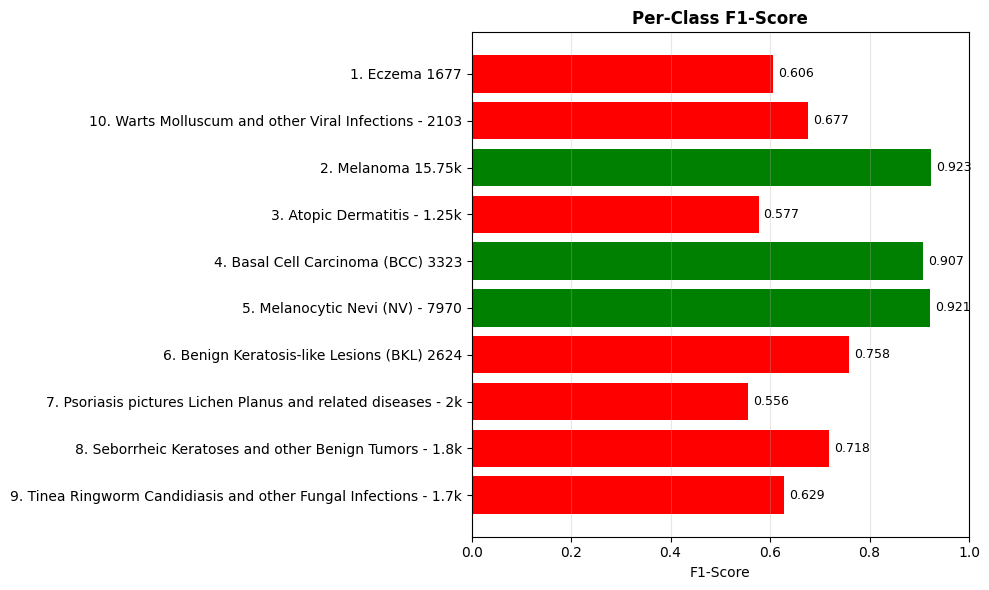


Results saved to /kaggle/working/outputs/evaluation


{'overall': {'accuracy': 0.7944277108433735,
  'precision_macro': 0.7270111812541558,
  'recall_macro': 0.7383683321830958,
  'f1_macro': 0.7273192511748034,
  'precision_weighted': 0.8071730642753813,
  'recall_weighted': 0.7944277108433735,
  'f1_weighted': 0.7968288609645328},
 'per_class': {'1. Eczema 1677': {'precision': 0.5397350993377483,
   'recall': 0.690677966101695,
   'f1': 0.6059479553903345,
   'support': 236},
  '10. Warts Molluscum and other Viral Infections - 2103': {'precision': 0.6678200692041523,
   'recall': 0.6868327402135231,
   'f1': 0.6771929824561403,
   'support': 281},
  '2. Melanoma 15.75k': {'precision': 0.8805394990366089,
   'recall': 0.970276008492569,
   'f1': 0.9232323232323232,
   'support': 471},
  '3. Atopic Dermatitis - 1.25k': {'precision': 0.5020576131687243,
   'recall': 0.6777777777777778,
   'f1': 0.5768321513002365,
   'support': 180},
  '4. Basal Cell Carcinoma (BCC) 3323': {'precision': 0.9041916167664671,
   'recall': 0.9096385542168675,


In [13]:
def full_evaluation(models_dir=MODELS_DIR, data_dir=DATA_PROC):
    model_path = models_dir / 'final' / 'skin_disease_classifier.keras'
    if not model_path.exists():
        print('Run Cell 9 first.'); return

    model = keras.models.load_model(str(model_path))
    with open(models_dir / 'final' / 'class_names.json') as f:
        class_names = json.load(f)

    # Test generator: rescale only, shuffle=False (essential for correct label alignment)
    test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        data_dir / 'test',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
    )
    # Reset generator pointer to position 0 before prediction
    test_gen.reset()

    print(f'Evaluating on {test_gen.samples} test samples...')
    y_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    acc  = accuracy_score(y_true, y_pred)
    pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average='macro',    zero_division=0)
    pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{"="*60}')
    print(f'  Accuracy            : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Macro   P/R/F1      : {pm:.4f} / {rm:.4f} / {fm:.4f}')
    print(f'  Weighted P/R/F1     : {pw:.4f} / {rw:.4f} / {fw:.4f}')
    print(f'{"="*60}')

    ppc, rpc, fpc, spc = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0)
    print(f'\n{"Class":<55} {"P":>7} {"R":>7} {"F1":>7} {"N":>7}')
    print('-'*85)
    for i, cn in enumerate(class_names):
        print(f'{cn:<55} {ppc[i]:>7.3f} {rpc[i]:>7.3f} {fpc[i]:>7.3f} {spc[i]:>7.0f}')

    save_dir = OUTPUTS_DIR / 'evaluation'
    save_dir.mkdir(parents=True, exist_ok=True)
    metrics = {
        'overall'  : {'accuracy': float(acc),
                      'precision_macro': float(pm), 'recall_macro': float(rm), 'f1_macro': float(fm),
                      'precision_weighted': float(pw), 'recall_weighted': float(rw), 'f1_weighted': float(fw)},
        'per_class': {cn: {'precision': float(ppc[i]), 'recall': float(rpc[i]),
                            'f1': float(fpc[i]), 'support': int(spc[i])}
                      for i, cn in enumerate(class_names)},
    }
    with open(save_dir / 'evaluation_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)
    pd.DataFrame(metrics['per_class']).T.to_csv(save_dir / 'classification_report.csv')

    # F1 bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green' if v >= 0.9 else 'orange' if v >= 0.8 else 'red' for v in fpc]
    ax.barh(class_names, fpc, color=colors)
    ax.set_xlabel('F1-Score'); ax.set_title('Per-Class F1-Score', fontweight='bold')
    ax.set_xlim(0, 1); ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(fpc):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(save_dir / 'f1_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nResults saved to {save_dir}')
    return metrics


full_evaluation()


## Cell 14 — Confusion Matrix & Misclassification Analysis

Found 3984 images belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step


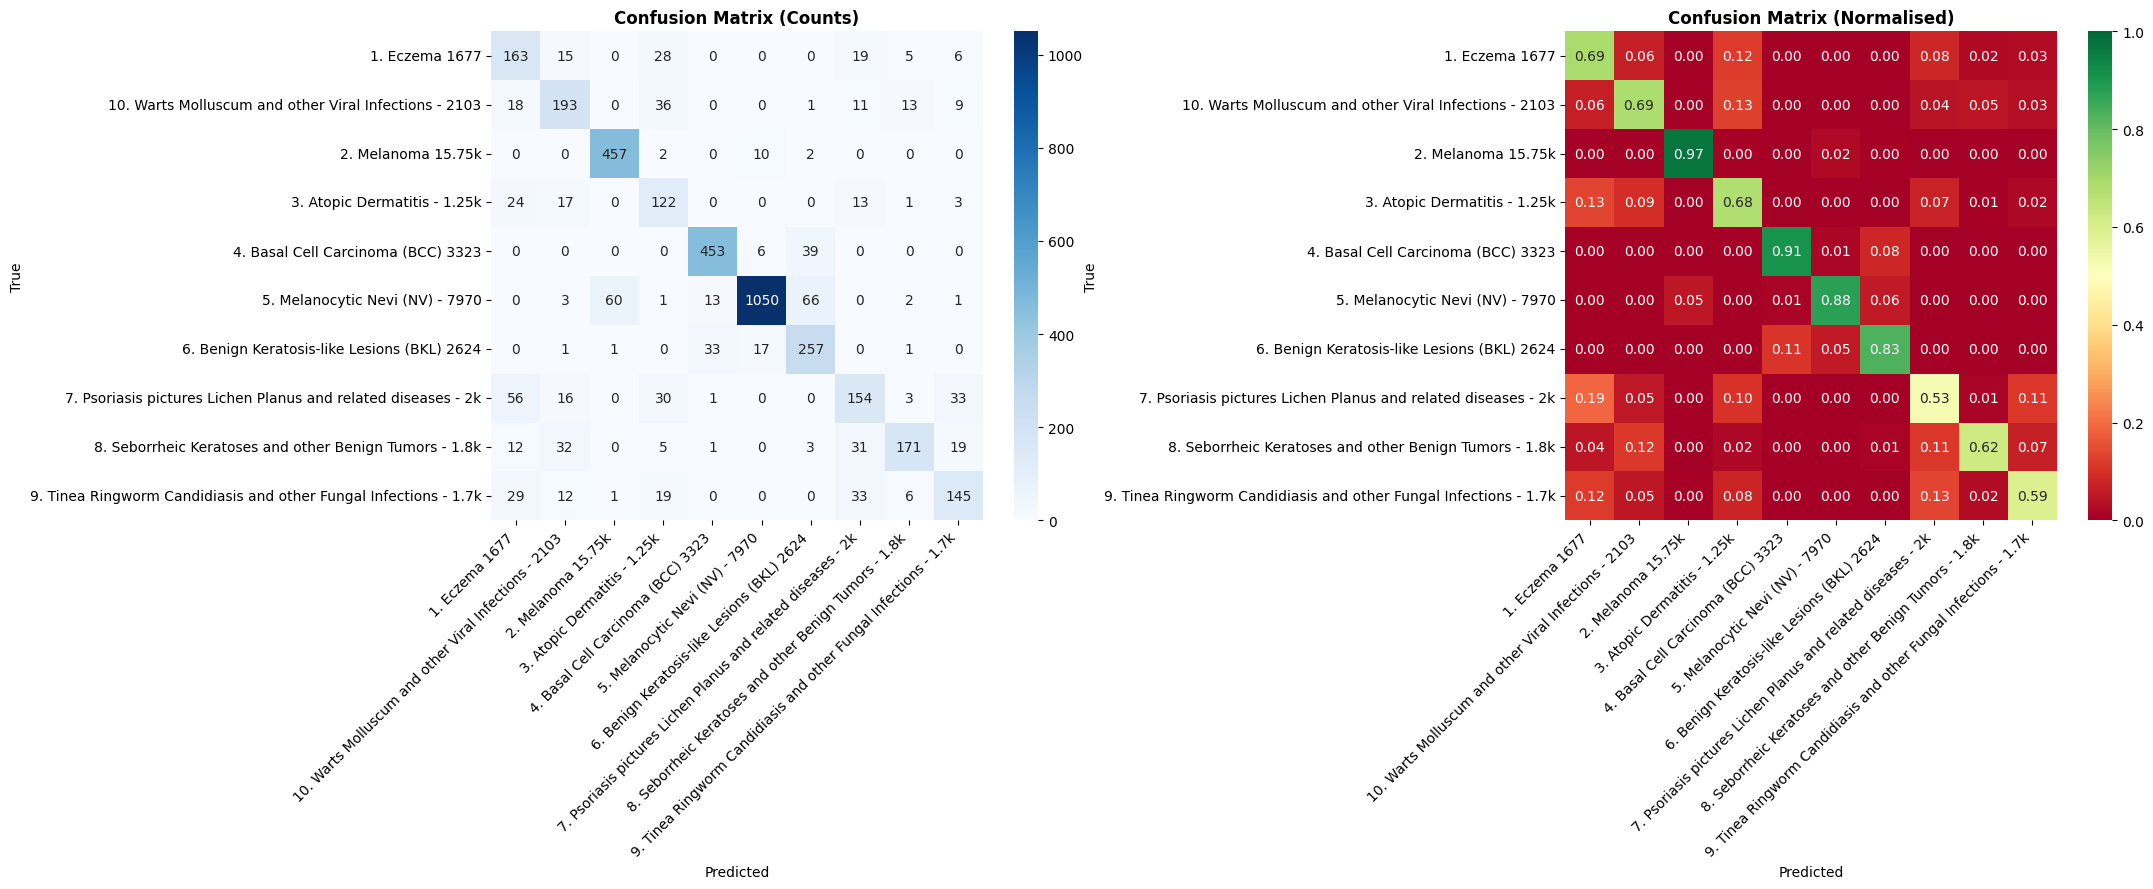


Top 10 Misclassifications:
True                                               -> Predicted                                              N  % of True
-------------------------------------------------------------------------------------------------------------------
5. Melanocytic Nevi (NV) - 7970                    -> 6. Benign Keratosis-like Lesions (BKL) 2624           66       5.5%
5. Melanocytic Nevi (NV) - 7970                    -> 2. Melanoma 15.75k                                    60       5.0%
7. Psoriasis pictures Lichen Planus and related diseases - 2k -> 1. Eczema 1677                                        56      19.1%
4. Basal Cell Carcinoma (BCC) 3323                 -> 6. Benign Keratosis-like Lesions (BKL) 2624           39       7.8%
10. Warts Molluscum and other Viral Infections - 2103 -> 3. Atopic Dermatitis - 1.25k                          36      12.8%
6. Benign Keratosis-like Lesions (BKL) 2624        -> 4. Basal Cell Carcinoma (BCC) 3323                    33

In [14]:
def confusion_matrix_analysis(models_dir=MODELS_DIR, data_dir=DATA_PROC):
    model_path = models_dir / 'final' / 'skin_disease_classifier.keras'
    if not model_path.exists():
        print('Run Cell 9 first.'); return

    model = keras.models.load_model(str(model_path))
    with open(models_dir / 'final' / 'class_names.json') as f:
        class_names = json.load(f)

    test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        data_dir / 'test',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
    )
    test_gen.reset()   # reset pointer before prediction

    y_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    for ax, data, fmt, title, cmap in [
        (axes[0], cm,      'd',   'Confusion Matrix (Counts)',     'Blues'),
        (axes[1], cm_norm, '.2f', 'Confusion Matrix (Normalised)', 'RdYlGn'),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, vmin=0, vmax=1 if fmt == '.2f' else None)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('True'); ax.set_xlabel('Predicted')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    vis_dir = OUTPUTS_DIR / 'visualizations'
    vis_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(vis_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Top 10 misclassifications
    n = len(class_names)
    miscls = sorted(
        [{'true': class_names[i], 'pred': class_names[j],
          'count': int(cm[i,j]), 'pct': cm[i,j]/cm[i].sum()*100}
         for i in range(n) for j in range(n) if i != j and cm[i,j] > 0],
        key=lambda x: -x['count']
    )
    print(f'\nTop 10 Misclassifications:')
    print(f'{"True":<50} -> {"Predicted":<50} {"N":>5} {"% of True":>10}')
    print('-'*115)
    for m in miscls[:10]:
        print(f'{m["true"]:<50} -> {m["pred"]:<50} {m["count"]:>5} {m["pct"]:>9.1f}%')

    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        vis_dir / 'confusion_matrix.csv')
    pd.DataFrame(cm_norm, index=class_names, columns=class_names).to_csv(
        vis_dir / 'confusion_matrix_normalized.csv')
    print(f'\nCSVs saved to {vis_dir}')


confusion_matrix_analysis()


## Cell 15 — Finalize Model (freeze + model card)

In [15]:
def finalize_model(models_dir=MODELS_DIR):
    src = models_dir / 'final' / 'skin_disease_classifier.keras'
    if not src.exists():
        print('Run Cell 9 first.'); return

    model = keras.models.load_model(str(src))

    # Freeze all layers for inference-only deployment
    for layer in model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print('All layers frozen (inference-only mode)')

    final_dir = models_dir / 'final'
    model.save(str(final_dir / 'skin_disease_classifier_frozen.keras'))
    model.save(str(final_dir / 'skin_disease_classifier_frozen.h5'))
    print('Frozen model saved (.keras + .h5)')

    with open(final_dir / 'class_names.json') as f:
        class_names = json.load(f)

    summary_path = OUTPUTS_DIR / 'training' / 'summary.json'
    training_summary = json.load(open(summary_path)) if summary_path.exists() else {}

    eval_path = OUTPUTS_DIR / 'evaluation' / 'evaluation_metrics.json'
    eval_metrics = json.load(open(eval_path)).get('overall', {}) if eval_path.exists() else {}

    card = {
        'model_name'  : 'MediSkin AI — Skin Disease Classifier',
        'version'     : '1.0',
        'created'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'framework'   : f'TensorFlow {tf.__version__}',
        'architecture': {
            'base'       : 'ResNet50 (ImageNet pretrained)',
            'head'       : 'GAP -> Dense(512)+BN+ReLU+Dropout(0.5) -> Dense(256)+BN+ReLU+Dropout(0.3) -> Softmax',
            'input_shape': [IMG_SIZE, IMG_SIZE, 3],
            'num_classes': len(class_names),
            'class_names': class_names,
        },
        'training'    : training_summary,
        'performance' : eval_metrics,
        'inference'   : {
            'preprocessing': f'Resize to {IMG_SIZE}x{IMG_SIZE}, divide by 255',
            'output'       : f'Softmax over {len(class_names)} classes',
        },
        'files'       : {
            'frozen_keras': 'skin_disease_classifier_frozen.keras',
            'frozen_h5'   : 'skin_disease_classifier_frozen.h5',
            'class_names' : 'class_names.json',
        },
    }
    with open(final_dir / 'model_card.json', 'w') as f:
        json.dump(card, f, indent=2)

    print(f'\nModel card written: {final_dir / "model_card.json"}')
    print('\nAll final outputs:')
    for f in sorted(final_dir.iterdir()):
        print(f'  {f.name}  ({f.stat().st_size / 1024**2:.1f} MB)')


finalize_model()


All layers frozen (inference-only mode)


Frozen model saved (.keras + .h5)

Model card written: /kaggle/working/models/final/model_card.json

All final outputs:
  class_names.json  (0.0 MB)
  class_names.txt  (0.0 MB)
  label_mapping.json  (0.0 MB)
  model_card.json  (0.0 MB)
  severity_codes.csv  (0.0 MB)
  severity_levels.json  (0.0 MB)
  severity_summary.json  (0.0 MB)
  skin_disease_classifier.h5  (283.7 MB)
  skin_disease_classifier.keras  (472.6 MB)
  skin_disease_classifier_frozen.h5  (94.9 MB)
  skin_disease_classifier_frozen.keras  (95.2 MB)


## Cell 16 — Inference Example (single image)

In [16]:
def predict_image(image_path, models_dir=MODELS_DIR):
    """
    Classify a single skin image and show top-5 predictions + severity.
    Usage:
        predict_image('/kaggle/working/data/processed/test/<class>/<file>.jpg')
    """
    model_path = models_dir / 'final' / 'skin_disease_classifier_frozen.keras'
    if not model_path.exists():
        model_path = models_dir / 'final' / 'skin_disease_classifier.keras'

    model = keras.models.load_model(str(model_path))
    with open(models_dir / 'final' / 'class_names.json') as f:
        class_names = json.load(f)

    img = Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.expand_dims(np.array(img) / 255.0, 0).astype('float32')
    preds = model.predict(arr, verbose=0)[0]
    top5  = np.argsort(preds)[::-1][:5]

    print(f'\nImage: {Path(image_path).name}')
    print(f'\n  Rank  {"Class":<52} Confidence')
    print(f'  {"-"*70}')
    for rank, idx in enumerate(top5, 1):
        bar = chr(9608) * int(preds[idx] * 25)
        print(f'  {rank}.    {class_names[idx]:<52} {preds[idx]:>6.2%}  {bar}')

    best = class_names[top5[0]]
    sev  = get_severity(best)
    print(f'\n  Prediction : {best}')
    print(f'  Severity   : {sev["emoji"]} {sev["label"]}  — {sev["advice"]}')


# Demo: pick a random image from the test split
import random
random.seed(42)
test_imgs = list((DATA_PROC / 'test').rglob('*.jpg'))
if test_imgs:
    predict_image(str(random.choice(test_imgs)))
else:
    print('No test images found. Run Cell 6 first.')


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 6 variables whereas the saved optimizer has 4 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Image: 2._melanoma_15.75k_2360.jpg

  Rank  Class                                                Confidence
  ----------------------------------------------------------------------
  1.    2. Melanoma 15.75k                                   99.00%  ████████████████████████
  2.    5. Melanocytic Nevi (NV) - 7970                       0.42%  
  3.    4. Basal Cell Carcinoma (BCC) 3323                    0.16%  
  4.    10. Warts Molluscum and other Viral Infections - 2103  0.15%  
  5.    6. Benign Keratosis-like Lesions (BKL) 2624           0.12%  

  Prediction : 2. Melanoma 15.75k
  Severity   : 🔴 CRITICAL  — Seek IMMEDIATE medical attention.


## Cell 17 — Random Test Sample Grid

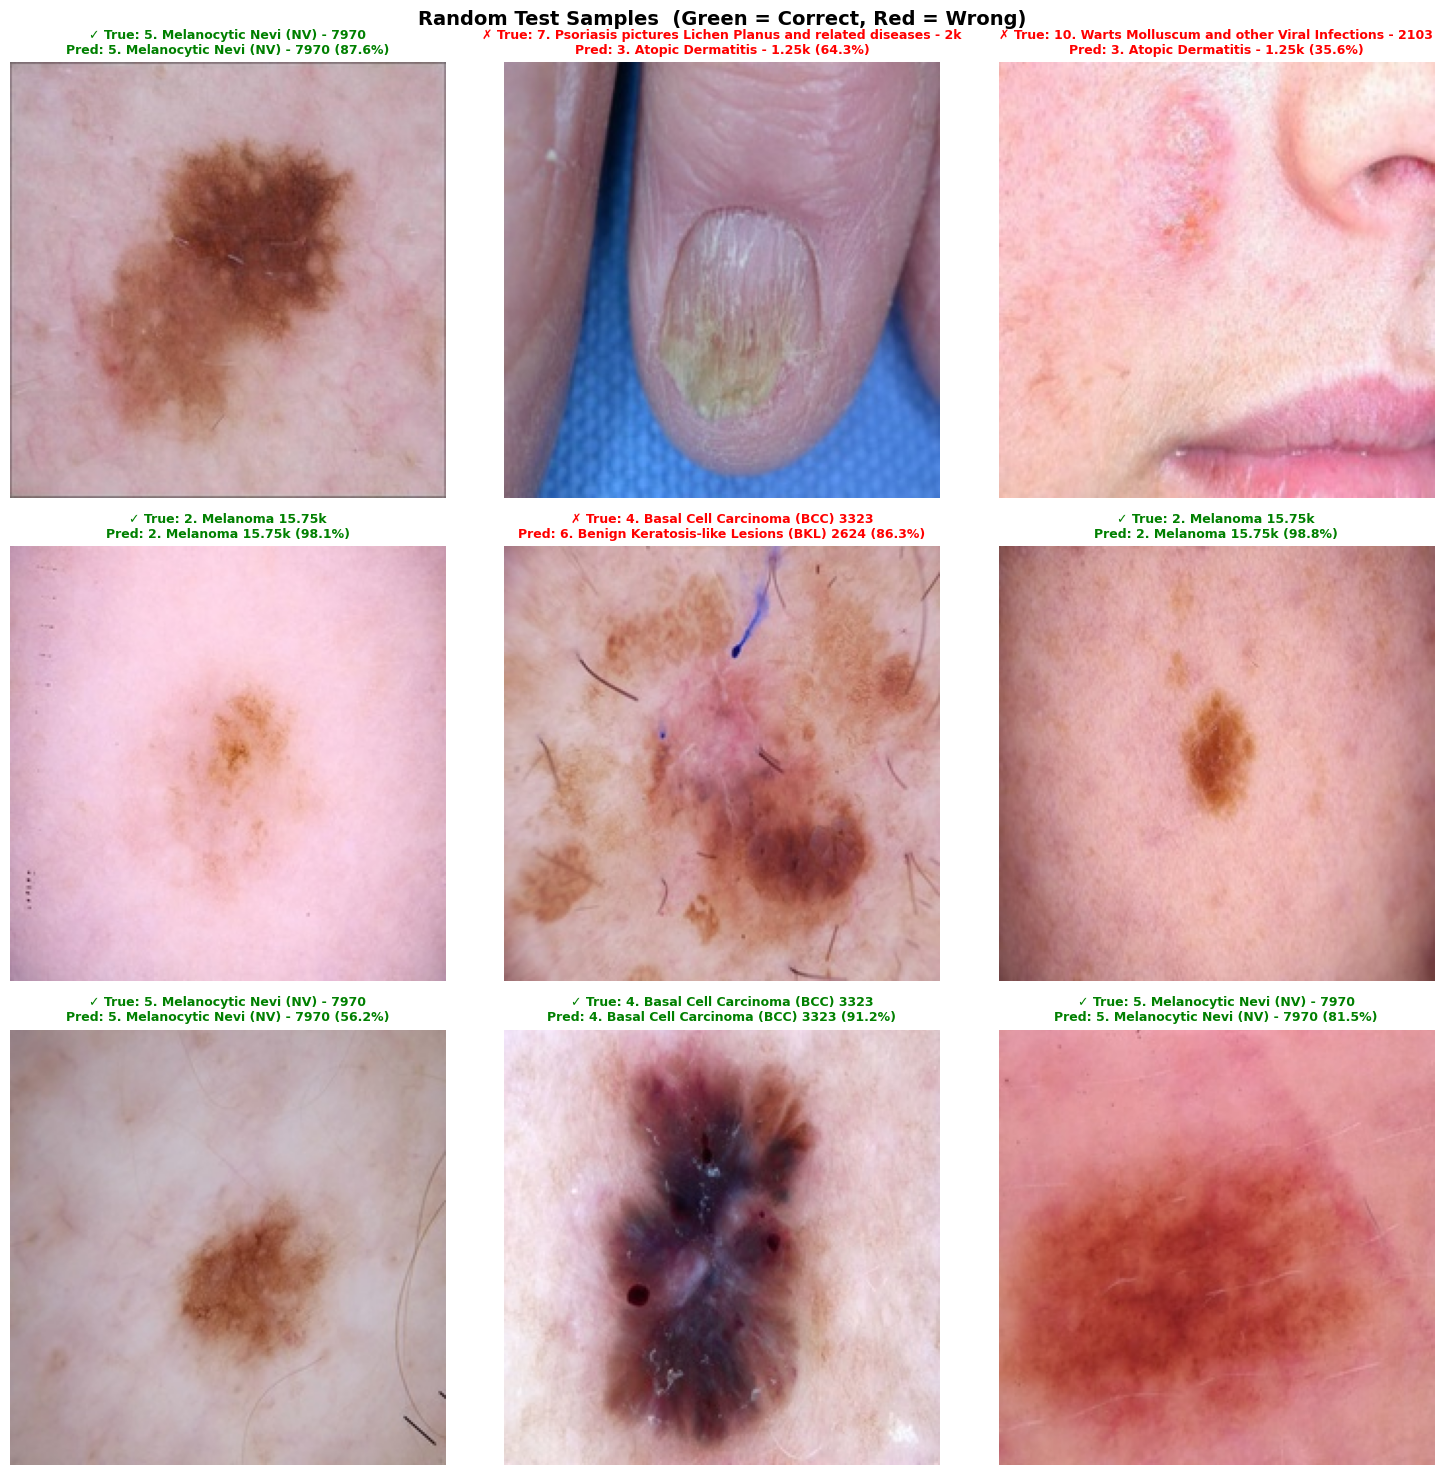


Sample accuracy: 6/9 (66.7%)

Misclassifications:
  True: 7. Psoriasis pictures Lichen Planus and related diseases - 2k  ->  Pred: 3. Atopic Dermatitis - 1.25k (64.3%)
  True: 10. Warts Molluscum and other Viral Infections - 2103  ->  Pred: 3. Atopic Dermatitis - 1.25k (35.6%)
  True: 4. Basal Cell Carcinoma (BCC) 3323  ->  Pred: 6. Benign Keratosis-like Lesions (BKL) 2624 (86.3%)


In [17]:
def test_random_samples(models_dir=MODELS_DIR, data_dir=DATA_PROC,
                         num_samples=9, seed=42):
    model_path = models_dir / 'final' / 'skin_disease_classifier.keras'
    if not model_path.exists():
        print('Run Cell 9 first.'); return

    model = keras.models.load_model(str(model_path))
    with open(models_dir / 'final' / 'class_names.json') as f:
        class_names = json.load(f)

    test_dir = data_dir / 'test'
    # Collect ALL test images (already in the held-out test split — no leakage)
    all_imgs = []
    for cls_dir in test_dir.iterdir():
        if cls_dir.is_dir():
            all_imgs.extend(list(cls_dir.glob('*.jpg')) +
                            list(cls_dir.glob('*.jpeg')) +
                            list(cls_dir.glob('*.png')))

    if not all_imgs:
        print(f'No images in {test_dir}'); return

    rng = np.random.default_rng(seed)
    samples = [all_imgs[i] for i in rng.choice(
        len(all_imgs), size=min(num_samples, len(all_imgs)), replace=False)]

    n_cols = 3
    n_rows = (len(samples) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = np.array(axes).flatten()

    results = []
    for ax, img_path in zip(axes, samples):
        true_label = img_path.parent.name
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        arr = np.expand_dims(np.array(img) / 255.0, 0)
        preds     = model.predict(arr, verbose=0)[0]
        pred_idx  = int(np.argmax(preds))
        pred_cls  = class_names[pred_idx]
        pred_conf = float(preds[pred_idx])
        correct   = (pred_cls == true_label)
        results.append({'true': true_label, 'pred': pred_cls,
                         'conf': pred_conf,  'correct': correct})
        ax.imshow(img)
        color = 'green' if correct else 'red'
        mark  = chr(10003) if correct else chr(10007)
        ax.set_title(f'{mark} True: {true_label}\nPred: {pred_cls} ({pred_conf:.1%})',
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')

    for ax in axes[len(samples):]:
        ax.axis('off')

    plt.suptitle('Random Test Samples  (Green = Correct, Red = Wrong)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    vis_dir = OUTPUTS_DIR / 'visualizations'
    vis_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(vis_dir / 'random_test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

    n_correct = sum(r['correct'] for r in results)
    print(f'\nSample accuracy: {n_correct}/{len(results)} ({n_correct/len(results):.1%})')
    wrong = [r for r in results if not r['correct']]
    if wrong:
        print('\nMisclassifications:')
        for r in wrong:
            print(f'  True: {r["true"]}  ->  Pred: {r["pred"]} ({r["conf"]:.1%})')


test_random_samples()
